# Multi-Layer Perceptron (MLP) Classification on Iris Dataset with PCA Visualization , Activation Function - ReLU and Pipeline

## Objective
The objective of this project is to classify Iris flower species using a Multi-Layer Perceptron (MLP) neural network with the **ReLU** activation function and to visualize the dataset in a reduced 2D space using Principal Component Analysis (PCA).  
This combines a nonlinear neural network model (MLP with ReLU) for classification and a linear dimensionality reduction technique (PCA) for better understanding of the data distribution.

## About the dataset
The Iris dataset is a classic multiclass classification dataset with:
- 150 samples
- 4 numerical features
- 3 target classes:
  - Setosa
  - Versicolor
  - Virginica


## Workflow

1. Import libraries
2. Load and understand the Iris dataset
3. Create a dataframe
4. Perform exploratory data analysis
5. Split the dataset into training and testing sets
6. Build and train an MLP pipeline using `StandardScaler` and `ReLU activation`
7. Evaluate the model using accuracy, confusion matrix, and classification report
8. Apply PCA for reduce the feature space to 2 dimensions(2D)
9. Visualize the data in 2D PCA space
10. Summarize the results

## Model and Techniques Used
- **MLPClassifier with ReLU activation**:
  - Hidden layer architecture: (10, 5)
  - Activation function: ReLU
  - Optimizer: Adam
  - Max iterations: 1000
  - Standardization of features using StandardScaler inside a scikit-learn Pipeline
- **PCA for visualization**:
  - Original feature space: 4 numerical features (sepal length, sepal width, petal length, petal width)
  - PCA reduced to 2 components to create a 2D scatter plot
  - The first two principal components together explain about 98% of the variance in the dataset.


In [1]:
# Step 1 - Import basic and necessary Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from warnings import filterwarnings
filterwarnings('ignore')
%matplotlib inline

## Load the Iris Dataset

In this step, the Iris dataset is loaded from `sklearn.datasets`.  
It provides the feature values, target labels, feature names, and target class names required for classification.

This dataset is widely used in machine learning because it is simple, balanced, and suitable for demonstrating multiclass classification techniques.

In [2]:
# Step 2 - Load dataset

from sklearn.datasets import load_iris
iris = load_iris()
print("Feature Names:", iris.feature_names,'\n','\n')
print("Target Names:", iris.target_names,'\n','\n')
print("Dataset Shape:", iris.data.shape)

Feature Names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)'] 
 

Target Names: ['setosa' 'versicolor' 'virginica'] 
 

Dataset Shape: (150, 4)


## Define Features and Target

The input features are stored in `X`, and the target labels are stored in `y`.

- `X` contains the 4 numerical flower measurements
- `y` contains the encoded class labels for the 3 Iris species

Separating features and target is an important step before splitting the dataset and training the model.

In [3]:
# Step 3 - Define feature and target

X = iris.data
y = iris.target

## Create a DataFrame

To make the dataset easier to inspect and analyze, the feature data is converted into a pandas DataFrame.

A new column named `species` is added using the target labels so the dataset becomes more readable and suitable for exploratory data analysis and visualization.

In [4]:
df = pd.DataFrame(X, columns=iris.feature_names)
df["species"] = y
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


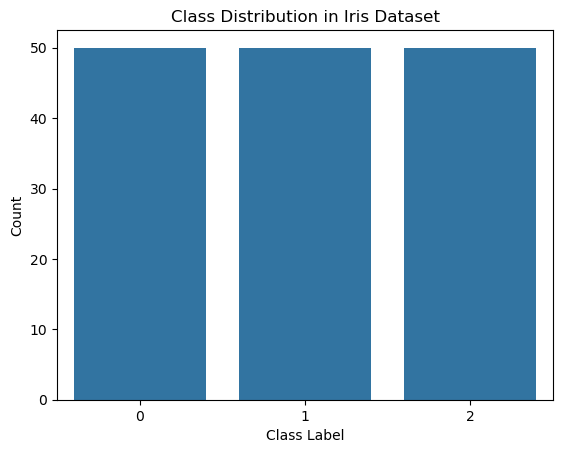

In [5]:
sns.countplot(x=y)
plt.title("Class Distribution in Iris Dataset")
plt.xlabel("Class Label")
plt.ylabel("Count")
plt.show()

### Class Distribution

The class distribution plot shows how the samples are distributed among the three flower species.

A balanced target distribution is beneficial because it reduces the risk of the model becoming biased toward one class during training.

## Train-Test Split

The dataset is divided into training and testing subsets.

- The training set is used to teach the model patterns from the data
- The testing set is used to evaluate how well the trained model performs on unseen samples

This helps measure the model’s generalization ability rather than only its memorization of the training data.

In [6]:
# Step 4 - Split data

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y ,
    test_size = 0.2,
    random_state = 42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((120, 4), (30, 4), (120,), (30,))

### Why Data Splitting Matters

A proper train-test split is essential in machine learning because evaluating the model on the same data used for training can give misleadingly high results.

Using separate test data gives a more realistic estimate of model performance.

#### We cannot create a normal scatter plot directly for the Iris dataset because it contains 4 features: sepal length, sepal width, petal length, and petal width.  
#### A scatter plot is easier to visualize in 2 dimensions, so Principal Component Analysis (PCA) is used to reduce the 4 original features into 2 principal components.

#### This helps represent the dataset in a single 2D scatter plot while preserving most of the important information from the original feature space.

### PCA Visualization Insight

The PCA scatter plot helps visualize the distribution of the three Iris species in a reduced 2D space.

This plot is useful because:
- It provides an intuitive visual summary of the dataset
- It shows how well the species are separated
- It supports the classification results by revealing the overall structure of the feature space

Although PCA is used here mainly for visualization, it also helps build intuition about class separability.

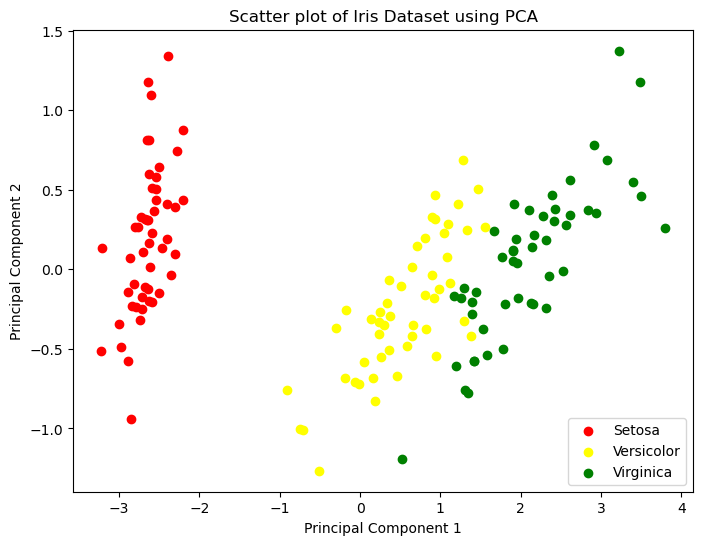

Explained variance ratio: [0.92461872 0.05306648]
Total variance explained: 0.98


In [7]:
# plotting scatter plot before modelling

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler_pca = StandardScaler()
X_scaled_for_pca = scaler_pca.fit_transform(X)

# Apply PCA to reduce to 2 dimensions
pca = PCA(n_components=2)               # As we need 2 dimensions so n_components = 2
X_pca = pca.fit_transform(X)

# Create a single scatter plot
plt.figure(figsize=(8, 6))

# Plot each class with a different color
plt.scatter(X_pca[y == 0, 0], X_pca[y == 0, 1], color='red', label='Setosa')
plt.scatter(X_pca[y == 1, 0], X_pca[y == 1, 1], color='yellow', label='Versicolor')
plt.scatter(X_pca[y == 2, 0], X_pca[y == 2, 1], color='green', label='Virginica')

# Add labels and legend
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Scatter plot of Iris Dataset using PCA')
plt.legend()
plt.savefig('Output_images\PCA visualization of Iris Dataset.png', dpi = 300, bbox_inches='tight')
plt.show()

# Print the explained variance ratio
print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total variance explained: {sum(pca.explained_variance_ratio_):.2f}")

### Explained Variance

The explained variance ratio shows how much information is captured by each principal component.

If the first two principal components together explain most of the variance, then the 2D PCA projection is a meaningful low-dimensional representation of the original dataset.

Here, the first two principal components explain around **98%** of the total variance, which means the PCA visualization retains most of the dataset’s important structure.

## Build the MLP Pipeline & Create Model

A scikit-learn Pipeline is used to combine preprocessing and model training into a single workflow.

This project uses:
- `StandardScaler()` for feature standardization
- `MLPClassifier()` for neural network classification

Using a pipeline improves code cleanliness, reproducibility, and reduces the chance of preprocessing mistakes.

The MLP model uses:
- Hidden layer sizes: `(10, 5)`
- Activation function: `ReLU`
- Solver: `adam`
- Maximum iterations: `1000`
- Random state: `42`

Feature scaling is important for neural networks because it helps the model converge more efficiently and improves learning performance.

In [8]:
# step 5 - Create model

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPClassifier


mlp_model = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPClassifier (hidden_layer_sizes = (10,5),
                           activation = 'relu',
                           max_iter = 1000,
                           random_state = 42))
])

### Why ReLU Activation is Used

ReLU (Rectified Linear Unit) is one of the most commonly used activation functions in neural networks.

It is preferred because:
- It is simple and computationally efficient
- It helps the model learn nonlinear patterns
- It often improves convergence compared to older activation functions such as sigmoid or tanh

That is why ReLU is used in this MLP model for the Iris classification task.

In [9]:
# Step 6 - Train model

mlp_model.fit(X_train, y_train)

,steps,"[('scaler', ...), ('mlp', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,hidden_layer_sizes,"(10, ...)"
,activation,'relu'
,solver,'adam'
,alpha,0.0001


### Model Training

The MLP model is trained on the scaled training data using the Adam optimizer.

The hidden layer architecture used in this project is `(10, 5)`, which means the neural network contains:
- One hidden layer with 10 neurons
- A second hidden layer with 5 neurons

This structure is sufficient for a small dataset like Iris while still demonstrating how a multi-layer neural network works.

In [10]:
# Step 7 - Predict-prediction

y_pred = mlp_model.predict(X_test)
y_pred

array([1, 0, 2, 1, 1, 0, 1, 2, 1, 1, 2, 0, 0, 0, 0, 1, 2, 1, 1, 2, 0, 2,
       0, 2, 2, 2, 2, 2, 0, 0])

After training, predictions are made on the test dataset.  
These predicted values are then compared with the actual test labels to measure model performance.

## Model Evaluation

Once the model is trained, its predictions on the test data are evaluated using multiple performance metrics.

The following metrics are used:
- Accuracy score
- Classification report
- Confusion matrix

Together, these metrics provide both overall and class-wise insight into the model’s performance.

In [11]:
# Step 8 - Evaluation

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy Score of model is {:.2f}".format(accuracy_score(y_test,y_pred) * 100),'%','\n')
print('Confusion Matrix :- \n', confusion_matrix(y_test, y_pred),'\n')
print('Classification Report :- \n', classification_report(y_test,y_pred))

Accuracy Score of model is 100.00 % 

Confusion Matrix :- 
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]] 

Classification Report :- 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



### Interpretation of Evaluation Metrics

- **Accuracy** shows the overall proportion of correctly classified samples
- **Precision** shows how many predicted samples of a class were actually correct
- **Recall** shows how many actual samples of a class were correctly identified
- **F1-score** balances precision and recall into a single value

These metrics are especially useful in multiclass classification because they provide a deeper understanding than accuracy alone.

The model achieved **100.00% accuracy** on the test dataset, which indicates excellent classification performance for this split of the Iris dataset.

The classification report also shows perfect precision, recall, and F1-score for all three classes.  
This suggests that the MLP model with feature scaling performed extremely well on this dataset.

> Note: The model achieved perfect performance on this specific train-test split of the Iris dataset.  
> Since the dataset is small and relatively well-structured, such results are possible, but additional validation methods such as cross-validation can provide a more robust estimate of generalization performance.

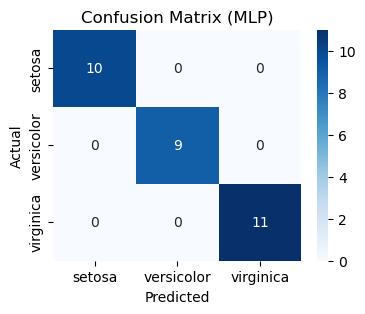

In [12]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize = (4,3))
sns.heatmap(cm, annot = True, fmt = "d", cmap = 'Blues',
            xticklabels = iris.target_names,
            yticklabels = iris.target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title("Confusion Matrix (MLP)")
plt.savefig('Output_images\Confusion Matrix (MLP).png', dpi = 300, bbox_inches='tight')
plt.show()

### Confusion Matrix Analysis

The confusion matrix gives a class-by-class breakdown of predictions.

It helps identify:
- Which classes are correctly classified most often
- Which classes are occasionally confused with each other

The confusion matrix shows that all classes were classified correctly:
- Setosa: 10 correct predictions
- Versicolor: 9 correct predictions
- Virginica: 11 correct predictions

## Conclusion

In this project, a Multi-Layer Perceptron (MLP) classifier was used to classify Iris flower species using four numerical input features with a preprocessing pipeline.

The model used:
- Hidden layer architecture: `(10, 5)`
- Activation function: `ReLU`
- Maximum iterations: `1000`
- Feature scaling through `StandardScaler()`

The model achieved **100.00% test accuracy**, and the confusion matrix showed correct classification for all test samples.

PCA was used to reduce the original 4-dimensional feature space into 2 dimensions for visualization.  
The first two principal components explained about **98% of the total variance**, which made the class distribution easier to visualize in a 2D scatter plot.

### Key achievements
- The Iris dataset was loaded and explored successfully  
- Exploratory Data Analysis was performed to understand the data structure  
- A preprocessing and modeling pipeline was built using `StandardScaler` and `MLPClassifier`  
- ReLU activation was used to enable nonlinear learning  
- The model was evaluated using accuracy, classification report, and confusion matrix  
- PCA reduced the dataset from 4 dimensions to 2 dimensions for visualization
- 
### Final understanding
Overall, the classification performance was excellent, and this project demonstrates how neural networks can be applied to multiclass classification problems in a clean and structured machine learning workflow.

It also shows the value of combining:
- preprocessing,
- neural network modeling,
- model evaluation,
- and dimensionality reduction

to create a complete and well-presented machine learning mini project.